Final data shape: (484, 9)
            garch_vol  lstm_pred   returns
Date                                      
2023-01-11   0.906807   0.007918 -0.001031
2023-01-12   0.860020   0.008100 -0.002098
2023-01-13   0.821055   0.008228  0.005495
2023-01-16   0.796666   0.008258 -0.003445
2023-01-17   0.771085   0.008208  0.008816


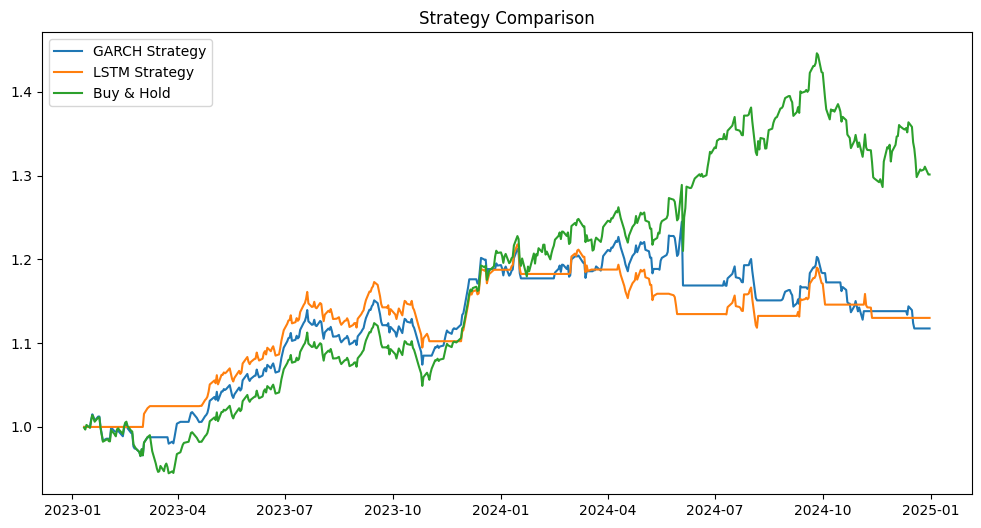

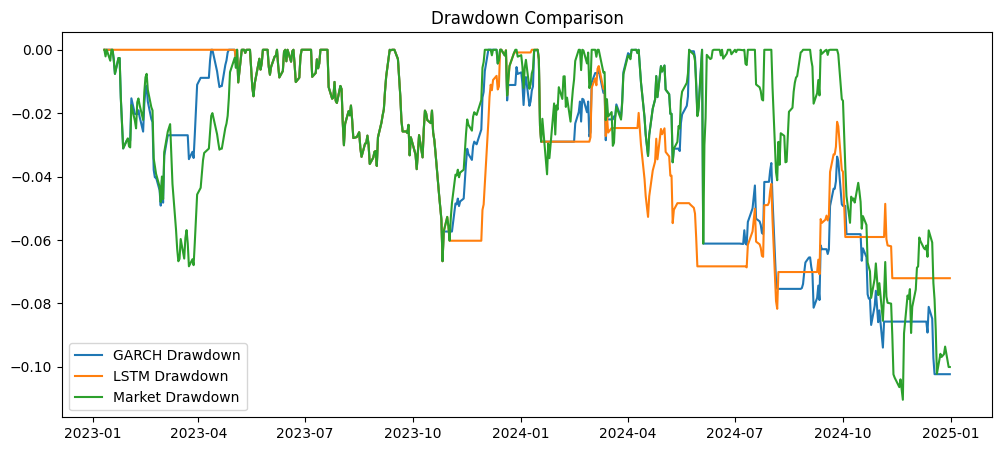


===== FINAL RESULTS =====
RETURNS:
GARCH Strategy: 1.1174991880943406
LSTM Strategy: 1.1301092270489403
Market: 1.301212200522576
 SHARPE:
GARCH Sharpe: 0.6195667492023412
LSTM Sharpe: 0.8598471774101507
Market Sharpe: 1.1918461389544157


In [ ]:

import sys, os
sys.path.append(os.path.abspath(".."))

from src.data_loader import load_data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# LOAD DATA
data = load_data("../data/nifty50_processed.csv")
data = data.dropna()

# Load model outputs
garch = pd.read_csv("../results/garch_results.csv", index_col=0)
lstm = pd.read_csv("../results/lstm_results.csv", index_col=0)

# Merge
data.index = pd.to_datetime(data.index)
garch.index = pd.to_datetime(garch.index)
lstm.index = pd.to_datetime(lstm.index)

# Sort indexes
data = data.sort_index()
garch = garch.sort_index()
lstm = lstm.sort_index()

# Merge properly
data = data.join(garch[['garch_vol']], how='inner')
data = data.join(lstm[['lstm_pred']], how='inner')

data = data.dropna()

print("Final data shape:", data.shape)
print(data[['garch_vol','lstm_pred','returns']].head())


# SHARPE FUNCTION
def sharpe_ratio(returns):
    returns = returns.dropna()
    if returns.std() == 0:
        return 0
    return np.mean(returns) / np.std(returns) * np.sqrt(252)


# Normalize volatility (Z-score)
vol_mean = data['garch_vol'].mean()
vol_std = data['garch_vol'].std()

data['vol_z'] = (data['garch_vol'] - vol_mean) / vol_std

# Smooth position (sigmoid)
threshold = data['garch_vol'].quantile(0.7)

data['garch_position'] = np.where(
    data['garch_vol'] < threshold,  # low volatility
    1,   # invest
    0    # stay out
)
# Returns
data['garch_strategy'] = data['garch_position'].shift(1) * data['returns']



# Normalize LSTM predictions
lstm_mean = data['lstm_pred'].mean()
lstm_std = data['lstm_pred'].std()

data['lstm_z'] = (data['lstm_pred'] - lstm_mean) / lstm_std

# Position
threshold = data['lstm_pred'].median()

data['lstm_position'] = np.where(
    data['lstm_pred'] < threshold,
    1,
    0
)

# Returns
data['lstm_strategy'] = data['lstm_position'].shift(1) * data['returns']

data[['garch_strategy', 'lstm_strategy']] = data[['garch_strategy', 'lstm_strategy']].fillna(0)

data['buy_hold'] = data['returns']


data['cum_garch'] = (1 + data['garch_strategy']).cumprod()
data['cum_lstm'] = (1 + data['lstm_strategy']).cumprod()
data['cum_market'] = (1 + data['buy_hold']).cumprod()


plt.figure(figsize=(12,6))
plt.plot(data['cum_garch'], label='GARCH Strategy')
plt.plot(data['cum_lstm'], label='LSTM Strategy')
plt.plot(data['cum_market'], label='Buy & Hold')
plt.legend()
plt.title("Strategy Comparison")
plt.show()


def drawdown(series):
    peak = series.cummax()
    return (series - peak) / peak

data['dd_garch'] = drawdown(data['cum_garch'])
data['dd_lstm'] = drawdown(data['cum_lstm'])
data['dd_market'] = drawdown(data['cum_market'])

plt.figure(figsize=(12,5))
plt.plot(data['dd_garch'], label='GARCH Drawdown')
plt.plot(data['dd_lstm'], label='LSTM Drawdown')
plt.plot(data['dd_market'], label='Market Drawdown')
plt.legend()
plt.title("Drawdown Comparison")
plt.show()

print("\n===== FINAL RESULTS =====")

print("RETURNS:")
print("GARCH Strategy:", data['cum_garch'].iloc[-1])
print("LSTM Strategy:", data['cum_lstm'].iloc[-1])
print("Market:", data['cum_market'].iloc[-1])

print(" SHARPE:")
print("GARCH Sharpe:", sharpe_ratio(data['garch_strategy'].dropna()))
print("LSTM Sharpe:", sharpe_ratio(data['lstm_strategy'].dropna()))
print("Market Sharpe:", sharpe_ratio(data['buy_hold'].dropna()))

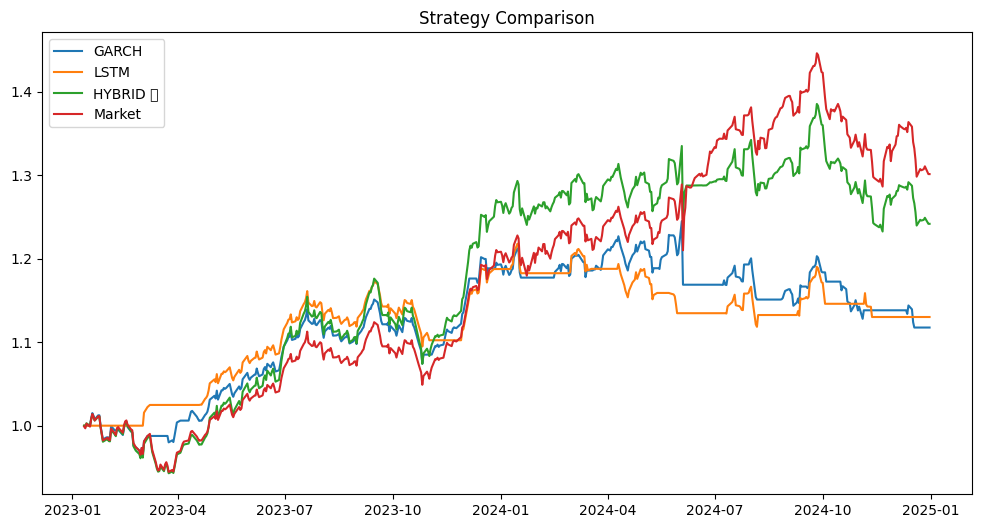

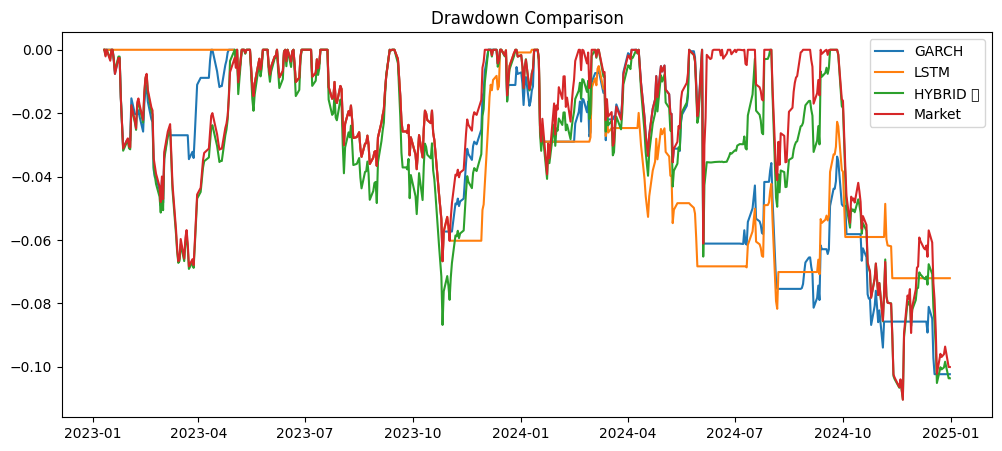

/Users/divyanshsingh/volatility-forecasting/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


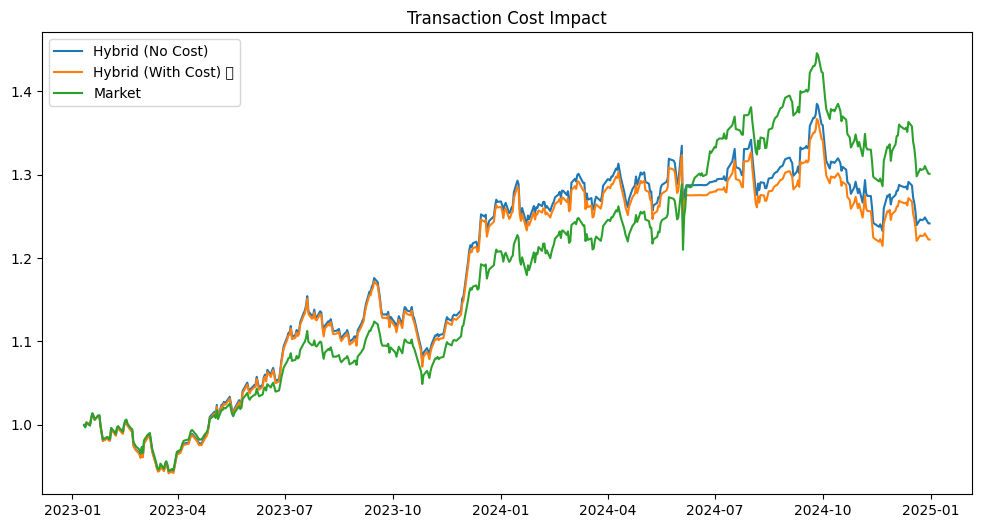

HYBRID Return: 1.2416689637554736
HYBRID Sharpe: 0.9385659586457624


In [ ]:

# Normalize signals
data['vol_z'] = (data['garch_vol'] - data['garch_vol'].mean()) / data['garch_vol'].std()
data['lstm_z'] = (data['lstm_pred'] - data['lstm_pred'].mean()) / data['lstm_pred'].std()

# Convert to signals
vol_signal = 1 / (1 + np.exp(data['vol_z']))
lstm_signal = 1 / (1 + np.exp(data['lstm_z']))

# Combine + leverage
# Stronger weighting (bias towards opportunity)
data['hybrid_position'] = 2.0 * (0.3 * vol_signal + 0.7 * lstm_signal)

# Cap exposure
data['hybrid_position'] = data['hybrid_position'].clip(0, 2)

# Cap exposure
data['hybrid_position'] = data['hybrid_position'].clip(0, 1.5)

data['hybrid_strategy'] = data['hybrid_position'].shift(1) * data['returns']

# Fill NA
data['hybrid_strategy'] = data['hybrid_strategy'].fillna(0)

# Cumulative
data['cum_hybrid'] = (1 + data['hybrid_strategy']).cumprod()



cost = 0.001  # 0.1% per trade

# Position change = trading activity
data['position_change'] = data['hybrid_position'].diff().abs()

# Cost applied
data['transaction_cost'] = data['position_change'] * cost

# Adjust returns
data['hybrid_strategy_net'] = data['hybrid_strategy'] - data['transaction_cost']

# New cumulative
data['cum_hybrid_net'] = (1 + data['hybrid_strategy_net']).cumprod()


data['trend'] = data['returns'].rolling(20).mean()

# Only allow positions in positive trend
data['hybrid_position'] = data['hybrid_position'] * (data['trend'] > 0)

plt.figure(figsize=(12,6))
plt.plot(data['cum_garch'], label='GARCH')
plt.plot(data['cum_lstm'], label='LSTM')
plt.plot(data['cum_hybrid'], label='HYBRID 🚀')
plt.plot(data['cum_market'], label='Market')
plt.legend()
plt.title("Strategy Comparison")
plt.show()



data['dd_hybrid'] = drawdown(data['cum_hybrid'])

plt.figure(figsize=(12,5))
plt.plot(data['dd_garch'], label='GARCH')
plt.plot(data['dd_lstm'], label='LSTM')
plt.plot(data['dd_hybrid'], label='HYBRID 🚀')
plt.plot(data['dd_market'], label='Market')
plt.legend()
plt.title("Drawdown Comparison")
plt.show()


plt.figure(figsize=(12,6))
plt.plot(data['cum_hybrid'], label='Hybrid (No Cost)')
plt.plot(data['cum_hybrid_net'], label='Hybrid (With Cost) 💰')
plt.plot(data['cum_market'], label='Market')
plt.legend()
plt.title("Transaction Cost Impact")
plt.show()

print("HYBRID Return:", data['cum_hybrid'].iloc[-1])
print("HYBRID Sharpe:", sharpe_ratio(data['hybrid_strategy']))

In [44]:
from sklearn.metrics import mean_squared_error

# Use squared returns as proxy for true volatility
actual_vol = data['returns']**2

garch_pred = data['garch_vol']
lstm_pred = data['lstm_pred']

df_compare = pd.DataFrame({
    'actual': actual_vol,
    'garch': garch_pred,
    'lstm': lstm_pred
}).dropna()

garch_rmse = np.sqrt(mean_squared_error(df_compare['actual'], df_compare['garch']))
lstm_rmse = np.sqrt(mean_squared_error(df_compare['actual'], df_compare['lstm']))

print("\n===== MODEL COMPARISON =====")
print(f"GARCH RMSE: {garch_rmse:.6f}")
print(f"LSTM RMSE: {lstm_rmse:.6f}")


===== MODEL COMPARISON =====
GARCH RMSE: 0.824793
LSTM RMSE: 0.007621
